# Coding Project 1: Linear Regression and Regularization

**Please write the names of all group members here:**




---

*Note:* The provided structure for the code below is only suggestive. You may structure your program differently, provided that your notebook is readable, reproducible, and answers all questions clearly.

A minimal `sklearn` workflow example is included before Question 3. It is intended to illustrate the use of `ColumnTransformer`, `Pipeline`, and `GridSearchCV`; it does **not** solve the project questions for you.

### Question 1 - Importing and Preparing the Data

In [2]:
%pip install --upgrade --force-reinstall matplotlib pandas numpy scipy scikit-learn

  Using cached matplotlib-3.11.2-cp312-cp312-macosx_11_0_arm64.whl.metadata (80 kB)
  Using cached pandas-3.0.6-cp312-cp312-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached numpy-2.5.3-cp312-cp312-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached scipy-1.18.1-cp312-cp312-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached scikit_learn-1.9.1-cp312-cp312-macosx_12_0_arm64.whl.metadata (9.3 kB)
  Using cached contourpy-1.4.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.66.1-cp312-cp312-macosx_10_13_universal2.whl.metadata (130 kB)
  Using cached kiwisolver-1.5.1-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached packaging-26.3-py3-none-any.whl.metadata (3.5 kB)
  Using cached pillow-12.3.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.3.3-py3-none-any.whl.metadata (5.9 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.


Task 1.a ----------------------------------------------------

X: (1460, 79), y: (1460,) | numerical: 35, categorical: 44

Task 1.b ----------------------------------------------------



/var/folders/9_/51m0drvn29bc0q_f8x0y62jw0000gn/T/ipykernel_58852/3594586670.py:69: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[2].boxplot(sale_price, vert=False)


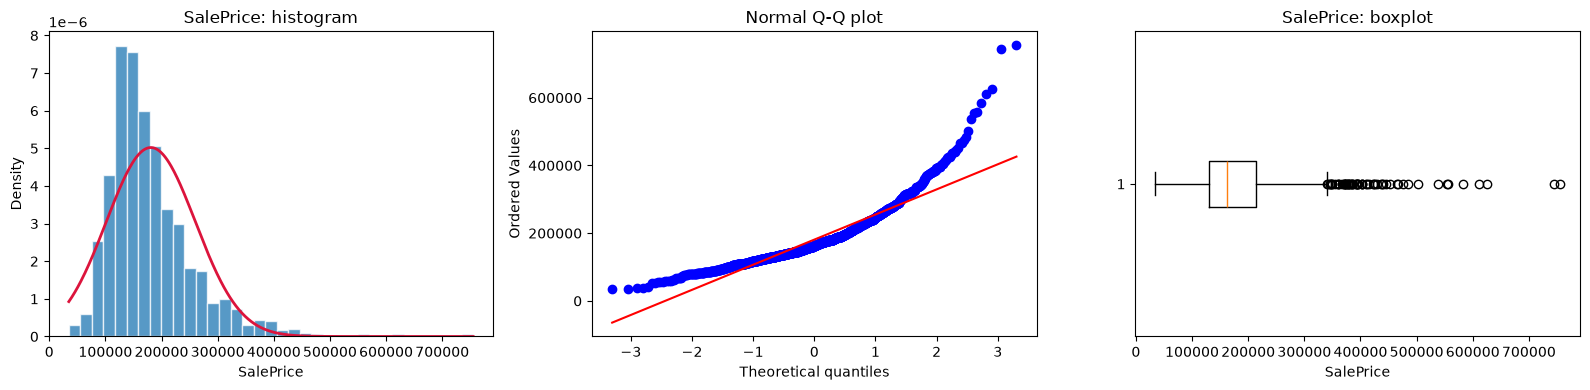

Skewness: 1.883
Excess kurtosis: 6.536
Mean: $180,921
Median: $163,000
 
Skewness: 1.883, indicating strong right-skewness.
Excess kurtosis: 6.536, indicating heavy tails.
Mean: approximately $180,921, greater than the median of $163,000.
The Q-Q plot should deviate substantially from the reference line, especially in the upper tail.
The boxplot should reveal several high-price observations.
 
Trasformation: log1p(SalePrice) to reduce skewness and heavy tails.
Original skewness:   1.883
Transformed skewness: 0.121
Original kurtosis:   6.536
Transformed kurtosis: 0.810


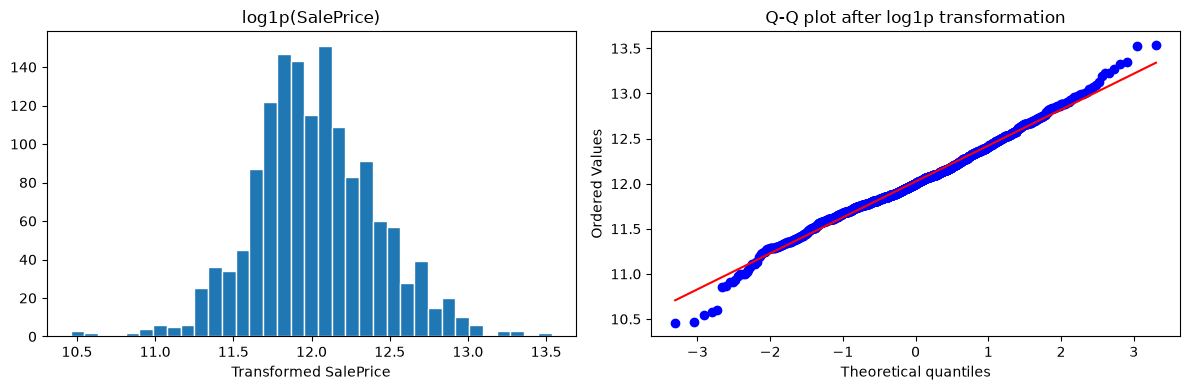


Task 1.c ----------------------------------------------------

Test Size:  30.0 % of the data
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape
(1022, 79) (438, 79) (1022,) (438,)

Task 1.d ----------------------------------------------------



In [10]:
# For Question 1, you may find the following packages useful:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy.stats as stats
import re
from sklearn.model_selection import train_test_split

# 1.a) Import Housing.csv as a pandas DataFrame.
# Separate the explanatory features X from the target y = SalePrice.
#
# Guidance:
# - Refer to data_description.txt to determine how variables should be interpreted.
# - The first column of the csv file is an index and should not be used as an explanatory variable.
# - Keep the original variable names so that later coefficient tables are easy to interpret.

# Variable types come from data_description.txt, not from the dtypes:
# MSSubClass is stored as integers but is categorical.

print("\nTask 1.a ----------------------------------------------------\n")


types = pd.Series(dict(re.findall(r"^(\w+) \((numerical|categorical)\):",
                                  open("data/data_description.txt").read(), flags=re.M)))
NUMERICAL = types.index[types == "numerical"].tolist()
CATEGORICAL = types.index[types == "categorical"].tolist()

# pandas' default reading turns 'NA' and 'None' into NaN, but for many categorical variables
# they are valid levels (e.g. 'NA' = "No Garage"). So only numerical 'NA' is read as missing;
# genuinely missing categorical values are handled in 1.d).
data = pd.read_csv("data/Housing.csv", index_col=0, keep_default_na=False,
                   na_values={col: ["NA"] for col in NUMERICAL},
                   dtype={col: str for col in CATEGORICAL})
X = data.drop(columns="SalePrice")
y = data["SalePrice"]

assert sorted(X.columns) == sorted(types.index)
print(f"X: {X.shape}, y: {y.shape} | numerical: {len(NUMERICAL)}, categorical: {len(CATEGORICAL)}")

print("\nTask 1.b ----------------------------------------------------\n")


# 1.b) Graphically determine whether SalePrice is approximately Gaussian.
# If it is not, suggest and apply a suitable transformation.
# Explain why considering such a transformation can be important.
#
# Guidance:
# - Use suitable graphical diagnostics (for example, a histogram and/or Q-Q plot).
# - Keep track of the transformation you choose because later questions require metrics
#   both on the transformed scale and, after inverse transformation, on the original
#   SalePrice scale.

sale_price = pd.to_numeric(y).dropna()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogram with fitted Gaussian reference curve
axes[0].hist(sale_price, bins=35, density=True, alpha=0.75, edgecolor="white")
mu, sigma = sale_price.mean(), sale_price.std()
x = np.linspace(sale_price.min(), sale_price.max(), 400)
axes[0].plot(x, stats.norm.pdf(x, mu, sigma), color="crimson", lw=2)
axes[0].set(title="SalePrice: histogram", xlabel="SalePrice", ylabel="Density")

# Normal Q-Q plot
stats.probplot(sale_price, dist="norm", plot=axes[1])
axes[1].set_title("Normal Q-Q plot")

# Boxplot
axes[2].boxplot(sale_price, vert=False)
axes[2].set(title="SalePrice: boxplot", xlabel="SalePrice")

plt.tight_layout()
plt.show()

print(f"Skewness: {sale_price.skew():.3f}")
print(f"Excess kurtosis: {sale_price.kurt():.3f}")
print(f"Mean: ${sale_price.mean():,.0f}")
print(f"Median: ${sale_price.median():,.0f}")
print(" ")
print("""Skewness: 1.883, indicating strong right-skewness.
Excess kurtosis: 6.536, indicating heavy tails.
Mean: approximately $180,921, greater than the median of $163,000.
The Q-Q plot should deviate substantially from the reference line, especially in the upper tail.
The boxplot should reveal several high-price observations.""")
print(" ")

print("Trasformation: log1p(SalePrice) to reduce skewness and heavy tails.")
# Preserve the original scale for later evaluation
y_original = y.copy()

# Transform the regression target
y = np.log1p(y_original)

print(f"Original skewness:   {y_original.skew():.3f}")
print(f"Transformed skewness: {y.skew():.3f}")
print(f"Original kurtosis:   {y_original.kurt():.3f}")
print(f"Transformed kurtosis: {y.kurt():.3f}")

# Confirm that inverse transformation recovers SalePrice
assert np.allclose(np.expm1(y), y_original)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y, bins=35, edgecolor="white")
axes[0].set(title="log1p(SalePrice)", xlabel="Transformed SalePrice")

stats.probplot(y, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot after log1p transformation")

plt.tight_layout()
plt.show()

print(f"""Why consider a transformation:
- OLS t-tests and confidence intervals (Question 2.b) assume normal errors with constant variance. With a
  right-skewed target the residuals are skewed and their spread usually grows with the price.
- On the log scale, feature effects are multiplicative: a coefficient beta means that the price changes by
  about 100*beta percent per standard deviation of the feature, which suits prices better than fixed dollar effects.
- Squared-error fitting would otherwise be dominated by the few very expensive houses in the right tail.
- After log1p the skewness falls from {y_original.skew():.3f} to {y.skew():.3f}, and the Q-Q plot is close to the
  reference line, apart from a few cheap houses in the lower tail.""")

print("\nTask 1.c ----------------------------------------------------\n")


# 1.c) Split the data into training and test sets.
# Randomly assign 70% of the observations to the training set and 30% to the test set.
#
# IMPORTANT:
# - Save an UNPROCESSED copy of X_train and X_test before doing any imputation,
#   standardization, or one-hot encoding.
# - You will return to these raw splits in Question 3.b) to build a leakage-safe
#   cross-validation pipeline.
#
# Suggested naming:
# X_train_raw, X_test_raw, y_train, y_test

# Train-test split
# modular test_size
TEST_SIZE = 0.3

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=42)

# as suggested, we keep copies for preprocessing in 1.d
X_train = X_train_raw.copy()
X_test = X_test_raw.copy()

print("Test Size: ", TEST_SIZE * 100, "% of the data")
print("X_train.shape, X_test.shape, Y_train.shape, Y_test.shape")
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

print("\nTask 1.d ----------------------------------------------------\n")


# 1.d) Prepare X_train and X_test using TRAINING-SET information only.
#
# Required steps:
# (i)   Numerical missing values: impute with the corresponding training-set mean.
# (ii)  Categorical missing values: impute with the most frequent category in the
#       corresponding training column.
# (iii) Treat 'NA' / 'None' as actual categorical levels where the data description
#       specifies that they are valid categories, rather than automatically treating
#       them as missing.
# (iv)  Standardize numerical features using training-set means and standard deviations,
#       and apply the same transformation, using these training-set statistics, to
#       the test set.
# (v)   One-hot encode the categorical variables.
# (vi)  Ensure that the test set contains the same encoded feature columns, in the
#       same order, as the training set.
#
# Hint:
# If pd.get_dummies is applied separately to the training and test sets, they may
# produce different dummy-variable columns because some categorical levels occur
# in only one of the two sets. The regression model must receive the same feature
# columns at training and prediction time. One possible way to align the encoded
# test columns to the training columns is:
#
# X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
#
# This creates any training dummy column missing from the test set and fills it
# with zero, while also matching the training-column order.
#
# Expected output / checks:
# - Report the final shapes of the prepared training and test feature matrices.
# - Verify that the encoded feature columns and their order are identical.
# - Do not use any test-set statistic to fit the preprocessing.

# 1.d) Training-only preprocessing

# Work from the raw splits
X_train = X_train_raw.copy()
X_test = X_test_raw.copy()

# Numerical features
X_train_num = X_train[NUMERICAL].apply(pd.to_numeric, errors="coerce")
X_test_num = X_test[NUMERICAL].apply(pd.to_numeric, errors="coerce")

train_means = X_train_num.mean()
train_stds = X_train_num.std().replace(0, 1)

# This performs z-score standardization to both training and testing dataset
X_train_num = (X_train_num.fillna(train_means) - train_means) / train_stds
X_test_num = (X_test_num.fillna(train_means) - train_means) / train_stds

# Categorical features
X_train_cat = X_train[CATEGORICAL].copy()
X_test_cat = X_test[CATEGORICAL].copy()

train_modes = X_train_cat.mode().iloc[0]

X_train_cat = X_train_cat.fillna(train_modes)
X_test_cat = X_test_cat.fillna(train_modes)

# One-hot encode: pd.get_dummies keeps one column for each of the k levels
X_train_cat = pd.get_dummies(X_train_cat, dtype=int)
X_test_cat = pd.get_dummies(X_test_cat, dtype=int)

# Match test columns to training columns
X_test_cat = X_test_cat.reindex(columns=X_train_cat.columns, fill_value=0)

# Combine numerical and categorical features
X_train = pd.concat([X_train_num, X_train_cat], axis=1)
X_test = pd.concat([X_test_num, X_test_cat], axis=1)


# assert checks that a condition is true.
assert X_train.columns.equals(X_test.columns)
print(f"Prepared X_train: {X_train.shape}, X_test: {X_test.shape}; same columns in the same order.")

### Question 2 - Linear Regression on Numerical Features


Task 2a ----------------------------------------------------



,feature,coefficient
0,Intercept,12.02890
1,LotFrontage,-0.00131
2,LotArea,0.02146
3,OverallQual,0.11434
4,OverallCond,0.04795
5,YearBuilt,0.09143
6,YearRemodAdd,0.02756
7,MasVnrArea,-0.00649
8,BsmtFinSF1,0.00973
9,BsmtFinSF2,0.00154


,sample,target_scale,MSE,R2
0,In-sample,log1p(SalePrice),0.02200,0.85810
1,Out-of-sample,log1p(SalePrice),0.02187,0.87109
2,In-sample,SalePrice (USD),1433790871.39794,0.76177
3,Out-of-sample,SalePrice (USD),829116179.68428,0.88118


On the log scale, MSE and R2 assess relative price errors, which is the scale  the model was trained to minimize. On the dollar scale, inverse-transformed  predictions show the practical size of errors in SalePrice; expensive homes  receive much more weight because their dollar errors are squared.

Task 2b ----------------------------------------------------



,feature,beta_numpy_solve,beta_sklearn,abs_difference
0,Intercept,12.02890,12.02890,0.00000
1,LotFrontage,-0.00131,-0.00131,0.00000
2,LotArea,0.02146,0.02146,0.00000
3,OverallQual,0.11434,0.11434,0.00000
4,OverallCond,0.04795,0.04795,0.00000
5,YearBuilt,0.09143,0.09143,0.00000
6,YearRemodAdd,0.02756,0.02756,0.00000
7,MasVnrArea,-0.00649,-0.00649,0.00000
8,BsmtFinSF1,0.64568,0.00973,0.63596
9,BsmtFinSF2,0.21061,0.00154,0.20906


 
Intercept (row 0, beta_0): numpy 12.02890 | sklearn 12.02890
 
Coefficients differing from sklearn by more than 1e-8: ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea']
 
Max |difference| between numpy and sklearn fitted values: 4.3e-14

- The intercept and 27 of the 35 slopes agree with sklearn (up to rounding). 

- The 8 area features strongly disagree, but both fits give the same fitted values.

- Reason (shown in (iv)): these columns are  linearly dependent, so A^T A is singular and the
  normal equations have infinitely many solutions.
  np.linalg.solve does not raise an error only because rounding errors make A^T A look invertible; it returns one arbitrary solution driven by rounding noise.
  sklearn uses a least-squares solver that returns the unique minimum-norm solution instead.

- Therefore the system is NOT numerically well behaved here: the solve-based coefficients of these
  8 features must not be interpreted (se

,feature,coefficient,standard_error
0,Intercept,12.02890,0.00472
1,LotFrontage,-0.00131,0.00628
2,LotArea,0.02146,0.00532
3,OverallQual,0.11434,0.00846
4,OverallCond,0.04795,0.00596
5,YearBuilt,0.09143,0.01084
6,YearRemodAdd,0.02756,0.00747
7,MasVnrArea,-0.00649,0.00564
8,BsmtFinSF1,0.64568,143269.83970
9,BsmtFinSF2,0.21061,48329.80775



Standard-error summary
Residual variance: sigma^2 = RSS / (m - p) = 22.47924 / 986 = 0.02280
Intercept: beta_0 = 12.02890, SE = 0.00472
Reliable coefficients: SEs range from 0.00472 to 0.01103
Example — OverallQual: coefficient = 0.11434, SE = 0.00846


A standard error measures how much a coefficient would change across similar samples.
Small standard errors mean the data can separate that feature's effect from the
effects of the other features.

The intercept is the predicted log sale price when every standardized feature is
at its training-set average. This is why beta_0 equals mean(y_train):
12.02890. Its SE is sigma / sqrt(m) = 0.00472.

Limitation:

8 area features are redundant: some are exact sums of
others. Think of trying to assign one total floor area between its component
areas—many coefficient combinations produce the same prediction. The prediction
is stable, but the individual area coefficients are not.

For those features, 4 SEs are extremely large
(up to 1.4e+05) and 

,target_scale,MSE_matrix_algebra,MSE_sklearn_2a,R2_matrix_algebra,R2_sklearn_2a
0,log1p(SalePrice),0.02200,0.02200,0.85810,0.85810
1,SalePrice (USD),1433790871.39792,1433790871.39794,0.76177,0.76177


In-sample MSE and R^2 agree with 2.a up to rounding (relative tolerance 1e-10): True

- They agree on both scales even though some coefficients differ from sklearn (see (i)).
- MSE and R^2 depend only on the fitted values A beta, i.e. the orthogonal projection of y onto the
  column space of A. This projection is unique even when beta is not.
A: 1022 x 36 | rank(A) = 34 | full column rank: False
Largest singular value:   84.54930
Smallest singular values: [1.182e+01 1.094e+01 9.910e+00 1.779e-14 1.629e-14]
Rank tolerance (matrix_rank): 1.9e-11 | pinv default cutoff: 8.5e-14
cond(A) = s_max / s_min = 5.2e+15 (1 / machine epsilon = 4.5e+15)
cond(A) without the two near-zero directions = s_max / s_34 = 8.5
Features in the null space of A: ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea']
TotalBsmtSF = BsmtFinSF1 + BsmtFinSF2 + BsmtUnfSF for every training row: True
GrLivArea = 1stFlrSF + 2ndFlrSF + LowQualFinSF for every training

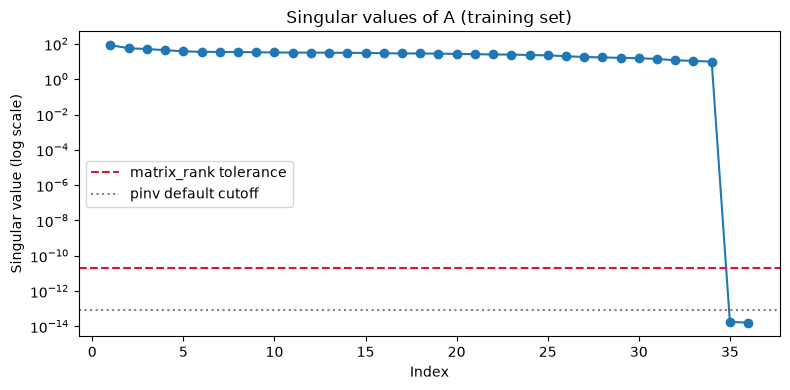


- A is NOT full column rank: rank 34 < 36 columns, so there are 2 exact linear dependencies.
- They are two accounting identities that hold in every training row (checked above):
  TotalBsmtSF = BsmtFinSF1 + BsmtFinSF2 + BsmtUnfSF and GrLivArea = 1stFlrSF + 2ndFlrSF + LowQualFinSF.
  Mean imputation changes nothing (these columns have no missing values), and z-scoring is affine, so the
  identities stay exact linear relations among the columns of A. The null space contains exactly these 8 features.
- The two smallest singular values (~1e-14) are zeros up to rounding, about 15 orders of magnitude below the
  next one (9.91). Apart from these two directions A is well conditioned (ratio ~9),
  so the problem is exact collinearity, not merely strong correlation.
- Link to (i)-(iii): cond(A) ~ 1 / machine epsilon, and the normal equations square it (cond(A^T A) = cond(A)^2),
  so A^T A is numerically singular. This explains the arbitrary solve-based coefficients and the exploding SEs
  of 

,feature,beta_solve,beta_pinv,se_solve,se_pinv
0,Intercept,12.02890,12.02890,0.00472,0.00472
1,LotFrontage,-0.00131,-0.00131,0.00628,0.00628
2,LotArea,0.02146,0.02146,0.00532,0.00532
3,OverallQual,0.11434,0.11434,0.00846,0.00846
4,OverallCond,0.04795,0.04795,0.00596,0.00596
5,YearBuilt,0.09143,0.09143,0.01084,0.01084
6,YearRemodAdd,0.02756,0.02756,0.00747,0.00747
7,MasVnrArea,-0.00649,-0.00649,0.00564,0.00564
8,BsmtFinSF1,0.64568,0.00973,143269.83970,0.00530
9,BsmtFinSF2,0.21061,0.00154,48329.80775,0.00489


Singular values discarded by pinv (below 8.5e-14): 2
Coefficients that change: ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea']
Standard errors that change: ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea']
sigma^2: solve 0.02279841 | pinv 0.02279841 | |difference| 2.4e-17
Max |beta_pinv - beta_sklearn|: 1.8e-15

- beta: unchanged for the intercept and the identified slopes. The 8 area features change: pinv sets
  1/s to zero for the two singular values below the cutoff and returns the unique minimum-norm solution.
  This is exactly the sklearn solution from 2.a.
- sigma^2: unchanged. Both solutions give the same fitted values, hence the same residuals and RSS.
- SEs: unchanged for the identified coefficients. For the 8 area features they go from huge or NaN
  values to 0.00471-0.00782, because the exploding 1/s^2 terms of the null directions are removed.
  Caveat: t

,feature,beta_statsmodels,se_statsmodels,beta_pinv,se_pinv,se_ratio_statsmodels_to_pinv
0,Intercept,12.02890,0.00472,12.02890,0.00472,0.99899
1,LotFrontage,-0.00131,0.00628,-0.00131,0.00628,0.99899
2,LotArea,0.02146,0.00531,0.02146,0.00532,0.99899
3,OverallQual,0.11434,0.00845,0.11434,0.00846,0.99899
4,OverallCond,0.04795,0.00595,0.04795,0.00596,0.99899
5,YearBuilt,0.09143,0.01083,0.09143,0.01084,0.99899
6,YearRemodAdd,0.02756,0.00746,0.02756,0.00747,0.99899
7,MasVnrArea,-0.00649,0.00564,-0.00649,0.00564,0.99899
8,BsmtFinSF1,0.00973,0.00530,0.00973,0.00530,0.99899
9,BsmtFinSF2,0.00154,0.00489,0.00154,0.00489,0.99899


Max |beta_statsmodels - beta_pinv|: 0.0e+00

Max |beta_statsmodels - beta_solve| (area features): 8.0e-01

statsmodels residual df = m - rank(A) = 1022 - 34 = 988
| formula above: m - (d + 1) = 986

sigma^2: statsmodels 0.02275226 | matrix algebra 0.02279841

SE ratio statsmodels / pinv: 0.998987 to 0.998987
 | sqrt(986 / 988) = 0.998987

Max |SE difference| after using the same df: 1.7e-18

Smallest eigenvalue of A^T A reported by statsmodels: 2.7e-28


- Coefficients: statsmodels matches the pinv (and sklearn) estimates up to rounding, including the
  8 area features. It does not match the solve-based values for these features (see (i)).

- Standard errors: all are smaller by the same factor 0.99899. The only cause is the degrees of freedom.
  statsmodels uses the numerical rank: df_resid = m - rank(A) = 988. The formula above uses m - (d + 1) = 986.
  After using the same df, the SEs match up to rounding.

- This discrepancy is a direct consequence of the rank deficiency found in (i

In [11]:
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm

# needed for task 2b
def show_and_save(table, file_name):
    """Display a table with 5 decimals (as in 2.a) and save it to output/."""
    with pd.option_context("display.float_format", "{:.5f}".format):
        display(table)
    table.to_csv(output_dir / file_name, index=False, float_format="%.5f")

#=============================================================================================

# 2.a) Fit an OLS regression using ONLY the numerical predictors and sklearn.
# Include an intercept.
#
# Required output:
# - A table with each numerical feature and its estimated regression coefficient.
# - In-sample and out-of-sample MSE and R^2.
# - If y was transformed in Question 1.b), report MSE and R^2:
#     * on the transformed target scale; and
#     * on the original SalePrice scale after inverse-transforming predictions.
# - Briefly explain what the two scales tell you about model performance.

print("\nTask 2a ----------------------------------------------------\n")


output_dir = Path("output")
output_dir.mkdir(exist_ok=True)

# The numerical predictors were imputed and standardized using training-set statistics in 1.d.
ols_numerical = LinearRegression(fit_intercept=True)
ols_numerical.fit(X_train_num, y_train)

ols_numerical_coefficients = pd.DataFrame({
    "feature": ["Intercept", *NUMERICAL],
    "coefficient": [ols_numerical.intercept_, *ols_numerical.coef_],
}).round(5)
ols_numerical_coefficients_display = ols_numerical_coefficients.copy()
ols_numerical_coefficients_display["coefficient"] = (
    ols_numerical_coefficients_display["coefficient"].map("{:.5f}".format)
 )
display(ols_numerical_coefficients_display)
ols_numerical_coefficients.to_csv(
    output_dir / "q2a_ols_numerical_coefficients.csv", index=False, float_format="%.5f"
 )

y_train_pred_log = ols_numerical.predict(X_train_num)
y_test_pred_log = ols_numerical.predict(X_test_num)

# log1p(SalePrice) was used in 1.b, so expm1 returns predictions in dollars.
y_train_original = y_original.loc[y_train.index]
y_test_original = y_original.loc[y_test.index]
y_train_pred_original = np.expm1(y_train_pred_log)
y_test_pred_original = np.expm1(y_test_pred_log)

ols_numerical_metrics = pd.DataFrame(
    [
        {
            "sample": "In-sample",
            "target_scale": "log1p(SalePrice)",
            "MSE": mean_squared_error(y_train, y_train_pred_log),
            "R2": r2_score(y_train, y_train_pred_log),
        },
        {
            "sample": "Out-of-sample",
            "target_scale": "log1p(SalePrice)",
            "MSE": mean_squared_error(y_test, y_test_pred_log),
            "R2": r2_score(y_test, y_test_pred_log),
        },
        {
            "sample": "In-sample",
            "target_scale": "SalePrice (USD)",
            "MSE": mean_squared_error(y_train_original, y_train_pred_original),
            "R2": r2_score(y_train_original, y_train_pred_original),
        },
        {
            "sample": "Out-of-sample",
            "target_scale": "SalePrice (USD)",
            "MSE": mean_squared_error(y_test_original, y_test_pred_original),
            "R2": r2_score(y_test_original, y_test_pred_original),
        },
    ]
).round(5)
ols_numerical_metrics_display = ols_numerical_metrics.copy()
ols_numerical_metrics_display["MSE"] = ols_numerical_metrics_display["MSE"].map(
    "{:.5f}".format
)
ols_numerical_metrics_display["R2"] = ols_numerical_metrics_display["R2"].map(
    "{:.5f}".format
)
display(ols_numerical_metrics_display)
ols_numerical_metrics.to_csv(
    output_dir / "q2a_ols_numerical_metrics.csv", index=False, float_format="%.5f"
 )

r2_log_train, r2_log_test, r2_usd_train, r2_usd_test = ols_numerical_metrics["R2"]
print(f"""
Comparison of the two scales:
- Log scale (the scale the model minimizes): MSE and R2 measure relative (percentage) errors. Train and test
  are almost equal (R2 {r2_log_train:.3f} vs {r2_log_test:.3f}), so the numerical model does not overfit.
- Dollar scale: MSE is in USD^2 and shows the practical size of the price errors. Squaring gives most weight to
  expensive houses and large misses. Here the in-sample R2 ({r2_usd_train:.3f}) is even lower than the
  out-of-sample R2 ({r2_usd_test:.3f}).
- Reason: two training houses, Id 1299 (5,642 sq ft, sold for $160,000, predicted $854,432) and Id 524
  (4,676 sq ft, sold for $184,750, predicted $668,492), cause about 49% of the in-sample squared dollar error.
  Both are very large houses sold cheaply in 'Partial' sales. Without them the in-sample R2 is about 0.88,
  close to the test value.
- So the log metrics describe the typical relative accuracy, while the dollar metrics are driven by a few
  large errors and by which outliers fall into each split.""")

#=============================================================================================



# 2.b) Reproduce and investigate OLS using matrix algebra on the TRAINING SET ONLY.
#
# Let A denote the design matrix containing the numerical predictors plus a column
# of ones for the intercept.
#
# (i) Compute the estimated coefficients using numpy.
#     Use a numerically stable linear-system solver such as np.linalg.solve(...)
#     whenever the system is numerically well behaved; do not explicitly form
#     a matrix inverse merely to solve the normal equations.
#
#     Expected output:
#     - Estimated intercept and feature coefficients.
#     - A comparison with the sklearn estimates from Question 2.a).

# Design matrix A = [1, X_train_num] of shape m x (d+1); column 0 is the intercept.
# Include the intercept and all numerical feature names.

print("\nTask 2b ----------------------------------------------------\n")

feature_names = ["Intercept", *NUMERICAL]
# Build the design matrix A by adding a column of ones for the intercept.
A = np.column_stack([np.ones(len(X_train_num)), X_train_num.to_numpy()])
y_vec = y_train.to_numpy()

# Get the number of observations and coefficients.
m, p = A.shape  # p = number of features + 1 intercept

# Compute AᵀA for the normal equation.
AtA = A.T @ A

# Solve the normal equation for the regression coefficients.
beta_solve = np.linalg.solve(AtA, A.T @ y_vec)

# Extract the intercept and coefficients from the scikit-learn model.
beta_sklearn = np.r_[ols_numerical.intercept_, ols_numerical.coef_]

# Compare the coefficients obtained by both methods.
q2b_coefficients = pd.DataFrame({
    "feature": feature_names,
    "beta_numpy_solve": beta_solve,
    "beta_sklearn": beta_sklearn,
    "abs_difference": np.abs(beta_solve - beta_sklearn),
})
show_and_save(q2b_coefficients, "q2b_i_coefficients_numpy_vs_sklearn.csv")

differing_features = q2b_coefficients.loc[
    q2b_coefficients["abs_difference"] > 1e-8, "feature"
].tolist()
print(" ")


# Compute predictions using the coefficients obtained with NumPy.
predictions_numpy = A @ beta_solve

# Compute predictions using the scikit-learn model.
predictions_sklearn = ols_numerical.predict(X_train_num)

# Find the largest absolute difference between the two predictions.
fitted_gap = np.abs(predictions_numpy - predictions_sklearn).max()

print(f"Intercept (row 0, beta_0): numpy {beta_solve[0]:.5f} | sklearn {beta_sklearn[0]:.5f}")
print(" ")
print(f"Coefficients differing from sklearn by more than 1e-8: {differing_features}")

print(" ")
print(f"Max |difference| between numpy and sklearn fitted values: {fitted_gap:.1e}")
print(f"""
- The intercept and {len(NUMERICAL) - len(differing_features)} of the {len(NUMERICAL)} slopes agree with sklearn (up to rounding). \n
- The {len(differing_features)} area features strongly disagree, but both fits give the same fitted values.\n
- Reason (shown in (iv)): these columns are  linearly dependent, so A^T A is singular and the
  normal equations have infinitely many solutions.
  np.linalg.solve does not raise an error only because rounding errors make A^T A look invertible; it returns one arbitrary solution driven by rounding noise.
  sklearn uses a least-squares solver that returns the unique minimum-norm solution instead.\n
- Therefore the system is NOT numerically well behaved here: the solve-based coefficients of these
  {len(differing_features)} features must not be interpreted (see (iv) and (v)).""")

#==============================================================================

# (ii) Compute the standard error of each estimated coefficient using numpy.
#
#      Expected output:
#      - A table containing coefficient estimates and their standard errors,
#        including the intercept.
#      - Clearly state which estimate corresponds to the intercept.

# residuals
residuals_solve = y_vec - A @ beta_solve
rss_solve = residuals_solve @ residuals_solve
sigma2_solve = rss_solve / (m - p)
# The SEs need the diagonal of (A^T A)^{-1} itself, so we solve (A^T A) X = I.
AtA_inv_diag = np.diag(np.linalg.solve(AtA, np.eye(p)))
# A negative diagonal entry is impossible for a true inverse; its SE is reported as NaN.
with np.errstate(invalid="ignore"):
    se_solve = np.sqrt(sigma2_solve * AtA_inv_diag)

q2b_standard_errors = pd.DataFrame({
    "feature": feature_names,
    "coefficient": beta_solve,
    "standard_error": se_solve,
})
show_and_save(q2b_standard_errors, "q2b_ii_coefficients_standard_errors.csv")

identified = ~q2b_coefficients["feature"].isin(differing_features).to_numpy()
identified_se = se_solve[identified]
redundant_se = se_solve[~identified]

print("\nStandard-error summary")
print("=" * 22)
print(f"Residual variance: sigma^2 = RSS / (m - p) = {rss_solve:.5f} / {m - p} = {sigma2_solve:.5f}")
print(f"Intercept: beta_0 = {beta_solve[0]:.5f}, SE = {se_solve[0]:.5f}")
print(f"Reliable coefficients: SEs range from {identified_se.min():.5f} to {identified_se.max():.5f}")
print(f"Example — OverallQual: coefficient = {beta_solve[feature_names.index('OverallQual')]:.5f}, "
      f"SE = {se_solve[feature_names.index('OverallQual')]:.5f}")

print(f"""

A standard error measures how much a coefficient would change across similar samples.
Small standard errors mean the data can separate that feature's effect from the
effects of the other features.

The intercept is the predicted log sale price when every standardized feature is
at its training-set average. This is why beta_0 equals mean(y_train):
{y_vec.mean():.5f}. Its SE is sigma / sqrt(m) = {np.sqrt(sigma2_solve / m):.5f}.

Limitation:

{len(differing_features)} area features are redundant: some are exact sums of
others. Think of trying to assign one total floor area between its component
areas—many coefficient combinations produce the same prediction. The prediction
is stable, but the individual area coefficients are not.

For those features, {np.sum(np.isfinite(redundant_se))} SEs are extremely large
(up to {np.nanmax(redundant_se):.1e}) and {np.sum(np.isnan(redundant_se))} are NaN.

A NaN occurs because floating-point rounding produced a negative value where a
variance should be non-negative. 

This is numerical evidence that the matrix is singular.

Conclusion: 
We should consider  the finite, modest SEs and NOT consider the large or NaN SEs for the redundant area variables.
We should then remove one variable from each exact relationship or use regularization to have stable coefficients.""")



# (iii) Using your matrix-algebra implementation, verify that the in-sample
#       MSE and R^2 agree with the corresponding results from Question 2.a),
#       up to numerical rounding.

def numpy_mse_r2(y_true, y_pred):
    """In-sample MSE and R^2 from their definitions."""
    residuals = y_true - y_pred
    return np.mean(residuals**2), 1 - residuals @ residuals / np.sum((y_true - y_true.mean()) ** 2)


fitted_solve = A @ beta_solve
mse_log, r2_log = numpy_mse_r2(y_vec, fitted_solve)
# Same inverse transformation as in 2.a: log1p -> expm1.
mse_usd, r2_usd = numpy_mse_r2(y_train_original.to_numpy(), np.expm1(fitted_solve))

q2b_in_sample_metrics = pd.DataFrame([
    {
        "target_scale": "log1p(SalePrice)",
        "MSE_matrix_algebra": mse_log,
        "MSE_sklearn_2a": mean_squared_error(y_train, y_train_pred_log),
        "R2_matrix_algebra": r2_log,
        "R2_sklearn_2a": r2_score(y_train, y_train_pred_log),
    },
    {
        "target_scale": "SalePrice (USD)",
        "MSE_matrix_algebra": mse_usd,
        "MSE_sklearn_2a": mean_squared_error(y_train_original, y_train_pred_original),
        "R2_matrix_algebra": r2_usd,
        "R2_sklearn_2a": r2_score(y_train_original, y_train_pred_original),
    },
])
show_and_save(q2b_in_sample_metrics, "q2b_iii_in_sample_metrics.csv")

metrics_match = np.allclose(
    q2b_in_sample_metrics[["MSE_matrix_algebra", "R2_matrix_algebra"]].to_numpy(),
    q2b_in_sample_metrics[["MSE_sklearn_2a", "R2_sklearn_2a"]].to_numpy(),
    rtol=1e-10,
)
print(f"In-sample MSE and R^2 agree with 2.a up to rounding (relative tolerance 1e-10): {metrics_match}")
print("""
- They agree on both scales even though some coefficients differ from sklearn (see (i)).
- MSE and R^2 depend only on the fitted values A beta, i.e. the orthogonal projection of y onto the
  column space of A. This projection is unique even when beta is not.""")



# (iv) Inspect the numerical structure of A.
#
#      Required diagnostics:
#      - rank of A;
#      - singular values of A.
#
#      Guidance:
#      - np.linalg.matrix_rank(...) and np.linalg.svd(..., compute_uv=False)
#        may be useful.
#      - Comment on whether A is full column rank.
#      - Inspect the smallest singular values and discuss whether they suggest
#        potential numerical instability.
#      - Relate this evidence to the OLS calculations above.

rank_A = np.linalg.matrix_rank(A)
_, singular_values, Vt = np.linalg.svd(A, full_matrices=False)
rank_tolerance = singular_values[0] * max(A.shape) * np.finfo(float).eps  # matrix_rank default
pinv_cutoff = 1e-15 * singular_values[0]  # np.linalg.pinv default cutoff

# Right singular vectors of the (near-)zero singular values span the null space of A.
null_directions = Vt[singular_values < rank_tolerance]
null_space_features = [
    name for name, loading in zip(feature_names, np.abs(null_directions).max(axis=0)) if loading > 1e-8
]
basement_identity = (
    X_train_raw["BsmtFinSF1"] + X_train_raw["BsmtFinSF2"] + X_train_raw["BsmtUnfSF"]
    == X_train_raw["TotalBsmtSF"]
).all()
living_area_identity = (
    X_train_raw["1stFlrSF"] + X_train_raw["2ndFlrSF"] + X_train_raw["LowQualFinSF"]
    == X_train_raw["GrLivArea"]
).all()

print(f"A: {m} x {p} | rank(A) = {rank_A} | full column rank: {rank_A == p}")
print(f"Largest singular value:   {singular_values[0]:.5f}")
print(f"Smallest singular values: {np.array2string(singular_values[-5:], precision=3)}")
print(f"Rank tolerance (matrix_rank): {rank_tolerance:.1e} | pinv default cutoff: {pinv_cutoff:.1e}")
print(f"cond(A) = s_max / s_min = {singular_values[0] / singular_values[-1]:.1e} "
      f"(1 / machine epsilon = {1 / np.finfo(float).eps:.1e})")
print(f"cond(A) without the two near-zero directions = s_max / s_{rank_A} = "
      f"{singular_values[0] / singular_values[rank_A - 1]:.1f}")
print(f"Features in the null space of A: {null_space_features}")
print(f"TotalBsmtSF = BsmtFinSF1 + BsmtFinSF2 + BsmtUnfSF for every training row: {basement_identity}")
print(f"GrLivArea = 1stFlrSF + 2ndFlrSF + LowQualFinSF for every training row: {living_area_identity}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(np.arange(1, p + 1), singular_values, "o-")
ax.axhline(rank_tolerance, color="crimson", ls="--", label="matrix_rank tolerance")
ax.axhline(pinv_cutoff, color="gray", ls=":", label="pinv default cutoff")
ax.set(title="Singular values of A (training set)", xlabel="Index", ylabel="Singular value (log scale)")
ax.legend()
plt.tight_layout()
fig.savefig(output_dir / "q2b_iv_singular_values.png", dpi=150)
plt.show()

print(f"""
- A is NOT full column rank: rank {rank_A} < {p} columns, so there are {p - rank_A} exact linear dependencies.
- They are two accounting identities that hold in every training row (checked above):
  TotalBsmtSF = BsmtFinSF1 + BsmtFinSF2 + BsmtUnfSF and GrLivArea = 1stFlrSF + 2ndFlrSF + LowQualFinSF.
  Mean imputation changes nothing (these columns have no missing values), and z-scoring is affine, so the
  identities stay exact linear relations among the columns of A. The null space contains exactly these 8 features.
- The two smallest singular values (~1e-14) are zeros up to rounding, about 15 orders of magnitude below the
  next one ({singular_values[rank_A - 1]:.2f}). Apart from these two directions A is well conditioned (ratio ~{singular_values[0] / singular_values[rank_A - 1]:.0f}),
  so the problem is exact collinearity, not merely strong correlation.
- Link to (i)-(iii): cond(A) ~ 1 / machine epsilon, and the normal equations square it (cond(A^T A) = cond(A)^2),
  so A^T A is numerically singular. This explains the arbitrary solve-based coefficients and the exploding SEs
  of the 8 area features. Fitted values, residuals, sigma^2, MSE and R^2 are unaffected because they depend
  only on the column space of A.""")



# (v) Replace the usual inverse-based expression by the Moore-Penrose pseudoinverse.
#     Use np.linalg.pinv(...) with its default cutoff.
#
#     Required comparison:
#     - Do the coefficient estimates change?
#     - Does the residual variance estimate change?
#     - Do the standard errors change?
#     - Explain when the ordinary inverse-based and pseudoinverse-based results
#       should agree and when they may differ, using the diagnostics from (iv).

A_pinv = np.linalg.pinv(A)  # default cutoff: 1e-15 * largest singular value
beta_pinv = A_pinv @ y_vec
residuals_pinv = y_vec - A @ beta_pinv
sigma2_pinv = residuals_pinv @ residuals_pinv / (m - p)
# (A^T A)^+ = A^+ (A^+)^T, so its diagonal is the squared row norm of A^+.
se_pinv = np.sqrt(sigma2_pinv * np.sum(A_pinv**2, axis=1))

q2b_pinv_comparison = pd.DataFrame({
    "feature": feature_names,
    "beta_solve": beta_solve,
    "beta_pinv": beta_pinv,
    "se_solve": se_solve,
    "se_pinv": se_pinv,
})
show_and_save(q2b_pinv_comparison, "q2b_v_solve_vs_pinv.csv")

beta_changed = q2b_pinv_comparison.loc[~np.isclose(beta_solve, beta_pinv, rtol=1e-8, atol=1e-10), "feature"].tolist()
se_changed = q2b_pinv_comparison.loc[~np.isclose(se_solve, se_pinv, rtol=1e-8, atol=1e-10), "feature"].tolist()
print(f"Singular values discarded by pinv (below {pinv_cutoff:.1e}): {np.sum(singular_values <= pinv_cutoff)}")
print(f"Coefficients that change: {beta_changed}")
print(f"Standard errors that change: {se_changed}")
print(f"sigma^2: solve {sigma2_solve:.8f} | pinv {sigma2_pinv:.8f} | |difference| {abs(sigma2_solve - sigma2_pinv):.1e}")
print(f"Max |beta_pinv - beta_sklearn|: {np.abs(beta_pinv - beta_sklearn).max():.1e}")
print(f"""
- beta: unchanged for the intercept and the identified slopes. The {len(beta_changed)} area features change: pinv sets
  1/s to zero for the two singular values below the cutoff and returns the unique minimum-norm solution.
  This is exactly the sklearn solution from 2.a.
- sigma^2: unchanged. Both solutions give the same fitted values, hence the same residuals and RSS.
- SEs: unchanged for the identified coefficients. For the {len(se_changed)} area features they go from huge or NaN
  values to {se_pinv[~identified].min():.5f}-{se_pinv[~identified].max():.5f}, because the exploding 1/s^2 terms of the null directions are removed.
  Caveat: these SEs describe the minimum-norm convention (the effect is spread across collinear columns);
  the separate effect of e.g. TotalBsmtSF versus its three components is still not identified by the data.
- When identical: if A has full column rank and all singular values are above the cutoff, then
  A^+ = (A^T A)^(-1) A^T, and both approaches agree up to rounding.
- When different: if A is rank deficient or has singular values below the cutoff. This is our case:
  (iv) found rank {rank_A} < {p} and two singular values (~1e-14) below the cutoff ({pinv_cutoff:.1e}).""")



# (vi) Confirm your results with statsmodels OLS.
#
#      Required output:
#      - Coefficient estimates and standard errors from statsmodels.
#      - Compare them with your matrix-algebra results up to numerical rounding.
#      - If they differ, relate the discrepancy to the rank / numerical-stability
#        diagnostics above.

# A already contains the intercept column. statsmodels fits with the pseudoinverse by default.
ols_statsmodels = sm.OLS(y_vec, A).fit()
beta_sm = ols_statsmodels.params
se_sm = ols_statsmodels.bse

q2b_statsmodels = pd.DataFrame({
    "feature": feature_names,
    "beta_statsmodels": beta_sm,
    "se_statsmodels": se_sm,
    "beta_pinv": beta_pinv,
    "se_pinv": se_pinv,
    "se_ratio_statsmodels_to_pinv": se_sm / se_pinv,
})
show_and_save(q2b_statsmodels, "q2b_vi_statsmodels_vs_matrix_algebra.csv")

rank_sm = int(ols_statsmodels.df_model) + 1  # df_model excludes the intercept
df_correction = np.sqrt((m - rank_sm) / (m - p))
print(f"Max |beta_statsmodels - beta_pinv|: {np.abs(beta_sm - beta_pinv).max():.1e}\n")
print(f"Max |beta_statsmodels - beta_solve| (area features): {np.abs(beta_sm - beta_solve).max():.1e}\n")
print(f"statsmodels residual df = m - rank(A) = {m} - {rank_sm} = {ols_statsmodels.df_resid:.0f}\n"
      f"| formula above: m - (d + 1) = {m - p}\n")
print(f"sigma^2: statsmodels {ols_statsmodels.scale:.8f} | matrix algebra {sigma2_pinv:.8f}\n")
print(f"SE ratio statsmodels / pinv: {(se_sm / se_pinv).min():.6f} to {(se_sm / se_pinv).max():.6f}\n "
      f"| sqrt({m - p} / {m - rank_sm}) = {np.sqrt((m - p) / (m - rank_sm)):.6f}\n")
print(f"Max |SE difference| after using the same df: {np.abs(se_sm * df_correction - se_pinv).max():.1e}\n")
print(f"Smallest eigenvalue of A^T A reported by statsmodels: {ols_statsmodels.eigenvals.min():.1e}\n")
print(f"""
- Coefficients: statsmodels matches the pinv (and sklearn) estimates up to rounding, including the
  {len(differing_features)} area features. It does not match the solve-based values for these features (see (i)).\n
- Standard errors: all are smaller by the same factor {(se_sm / se_pinv).mean():.5f}. The only cause is the degrees of freedom.
  statsmodels uses the numerical rank: df_resid = m - rank(A) = {m - rank_sm}. The formula above uses m - (d + 1) = {m - p}.
  After using the same df, the SEs match up to rounding.\n
- This discrepancy is a direct consequence of the rank deficiency found in (iv). With full column rank,
  rank(A) = d + 1, so both df and all results would coincide. statsmodels also flags the problem: the
  smallest eigenvalue of A^T A is ~{ols_statsmodels.eigenvals.min():.0e}, and its summary warns that the design matrix may be singular.\n
- In a rank-deficient design, m - rank(A) is the appropriate residual df. Dropping the redundant columns
  TotalBsmtSF and GrLivArea would give a full-rank A with identified coefficients and the same fit.\n""")

### Minimal sklearn Workflow Example (Illustration Only)

In [5]:
# This example demonstrates the WORKFLOW required in Question 3.b):
#
# raw data
#   -> ColumnTransformer
#   -> Pipeline
#   -> GridSearchCV
#   -> best hyperparameters / CV score
#   -> refitted best estimator
#   -> held-out test evaluation
#
# It uses a small artificial dataset and Ridge regression. It is NOT a solution
# to the housing problem, and its hyperparameter grid should not be copied blindly.

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.metrics import mean_squared_error

# ----- 1. Create a tiny mixed-type example dataset -----
rng = np.random.default_rng(1)
n = 60

X_example = pd.DataFrame({
    "size": rng.normal(100, 15, n),
    "age": rng.normal(20, 7, n),
    "region": rng.choice(["A", "B", "C"], size=n),
})

# Add a few missing values only to illustrate preprocessing.
X_example.loc[[2, 11, 31], "size"] = np.nan
X_example.loc[[5, 27], "region"] = np.nan

# Construct an arbitrary regression target.
region_effect = X_example["region"].map({"A": 0.0, "B": 5.0, "C": -3.0}).fillna(0.0)
y_example = (
    2.0 * X_example["size"].fillna(X_example["size"].mean())
    - 1.5 * X_example["age"]
    + region_effect
    + rng.normal(0, 5, n)
)

X_ex_train, X_ex_test, y_ex_train, y_ex_test = train_test_split(
    X_example, y_example, test_size=0.25, random_state=1
)

# ----- 2. Define preprocessing -----
numeric_features = ["size", "age"]
categorical_features = ["region"]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor_example = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

# ----- 3. Put preprocessing and the model in ONE pipeline -----
pipeline_example = Pipeline([
    ("preprocessor", preprocessor_example),
    ("model", Ridge()),
])

# Pipeline parameter names use step__parameter.
param_grid_example = {
    "model__alpha": [0.1, 1.0, 10.0],
}

# Define the CV folds once. The same idea can be used to ensure fair model comparisons.
cv_example = KFold(n_splits=4, shuffle=True, random_state=1)

search_example = GridSearchCV(
    estimator=pipeline_example,
    param_grid=param_grid_example,
    scoring="neg_mean_squared_error",
    cv=cv_example,
    refit=True,
)

# IMPORTANT:
# During each CV split, the preprocessing steps are fitted only on that fold's
# training observations because they are inside the Pipeline.
search_example.fit(X_ex_train, y_ex_train)

# ----- 4. Inspect the selected configuration and its CV performance -----
best_idx = search_example.best_index_
cv_mean_mse = -search_example.cv_results_["mean_test_score"][best_idx]
cv_std_mse = search_example.cv_results_["std_test_score"][best_idx]

print("Best parameters:", search_example.best_params_)
print(f"Mean CV MSE: {cv_mean_mse:.3f}")
print(f"Std. CV MSE: {cv_std_mse:.3f}")

# ----- 5. Final held-out test evaluation -----
# With refit=True (the default), best_estimator_ has already been refitted on ALL
# of X_ex_train using the selected hyperparameters.
best_model_example = search_example.best_estimator_
test_pred_example = best_model_example.predict(X_ex_test)
test_mse_example = mean_squared_error(y_ex_test, test_pred_example)

print(f"Test MSE: {test_mse_example:.3f}")

# Things to understand before Question 3.b):
# - Why must the preprocessing be inside the Pipeline during CV?
# - Why is the parameter called "model__alpha"?
# - What does refit=True do after CV selects the best hyperparameters?
# - Why should the held-out test set be used only after model selection?

# Visualize the structure of the pipeline
pipeline_example


Best parameters: {'model__alpha': 0.1}
Mean CV MSE: 26.085
Std. CV MSE: 12.683
Test MSE: 41.051


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

### Question 3 - Regularization Techniques

In [18]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.exceptions import ConvergenceWarning
import warnings

warnings.filterwarnings("ignore", category=ConvergenceWarning)


def usd_metrics(y_log, pred_log):
    """Evaluate log-target predictions on the original dollar scale."""
    return mean_squared_error(np.expm1(y_log), np.expm1(pred_log)), r2_score(np.expm1(y_log), np.expm1(pred_log))


def evaluate(model, fit_X, test_X):
    train_mse, train_r2 = usd_metrics(y_train, model.predict(fit_X))
    test_mse, test_r2 = usd_metrics(y_test, model.predict(test_X))
    return train_mse, train_r2, test_mse, test_r2


# 3.a) OLS using all prepared numerical and categorical features.
ols_all = LinearRegression().fit(X_train, y_train)
all_metrics = evaluate(ols_all, X_train, X_test)
num_metrics = (
    mean_squared_error(y_train_original, y_train_pred_original),
    r2_score(y_train_original, y_train_pred_original),
    mean_squared_error(y_test_original, y_test_pred_original),
    r2_score(y_test_original, y_test_pred_original),
)
ols_table = pd.DataFrame(
    [["OLS: numerical only", *num_metrics], ["OLS: all features", *all_metrics]],
    columns=["Model", "Train MSE", "Train R²", "Test MSE", "Test R²"],
)
display(ols_table.round(4))
mse_change = num_metrics[2] - all_metrics[2]
r2_change = all_metrics[3] - num_metrics[3]
print(f"3.a — Categories {'reduce' if mse_change > 0 else 'increase'} test MSE by ${abs(mse_change):,.0f} and change test R² by {r2_change:+.4f}.")
print(f"The train-to-test R² gap changes from {num_metrics[1] - num_metrics[3]:+.4f} to {all_metrics[1] - all_metrics[3]:+.4f}; a larger positive gap suggests overfitting.")


# 3.b.i) Preprocessing stays inside every CV fold to prevent leakage.
preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="mean")), ("scaler", StandardScaler())]), NUMERICAL),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), CATEGORICAL),
], sparse_threshold=0)
cv = KFold(n_splits=8, shuffle=True, random_state=42)

# 3.b.ii–iii) Each method uses this same preprocessor and these same CV folds.
models = {
    "Truncated pseudoinverse": (
        Pipeline([("preprocessor", preprocessor), ("svd", TruncatedSVD(random_state=42)), ("model", LinearRegression())]),
        {"svd__n_components": [25, 75, 125, 175]},
    ),
    "Ridge": (
        Pipeline([("preprocessor", preprocessor), ("model", Ridge(solver="lsqr"))]),
        {"model__alpha": np.logspace(-4, 5, 10)},
    ),
    "Lasso": (
        Pipeline([("preprocessor", preprocessor), ("model", Lasso(max_iter=100_000))]),
        {"model__alpha": np.logspace(-4, 0, 9)},
    ),
    "Elastic Net": (
        Pipeline([("preprocessor", preprocessor), ("model", ElasticNet(max_iter=100_000))]),
        {"model__alpha": np.logspace(-4, 0, 9), "model__l1_ratio": [0.05, 0.25, 0.50, 0.75, 0.95]},
    ),
}

searches, rows = {}, []
for name, (pipeline, grid) in models.items():
    search = GridSearchCV(pipeline, grid, scoring="neg_mean_squared_error", cv=cv, refit=True, n_jobs=1).fit(X_train_raw, y_train)
    searches[name] = search
    i = search.best_index_
    train_mse, train_r2, test_mse, test_r2 = evaluate(search.best_estimator_, X_train_raw, X_test_raw)
    rows.append([name, search.best_params_, -search.cv_results_["mean_test_score"][i], search.cv_results_["std_test_score"][i], train_mse, train_r2, test_mse, test_r2])
    boundary = [key for key, values in grid.items() if search.best_params_[key] in (min(values), max(values))]
    print(f"{name}: {'extend and rerun ' + str(boundary) if boundary else 'selected values are inside the final grid.'}")

regularized = pd.DataFrame(rows, columns=["Model", "Selected hyperparameter(s)", "Mean CV MSE", "Std CV MSE", "Train MSE", "Train R²", "Test MSE", "Test R²"])
summary = pd.concat([
    pd.DataFrame([["OLS: numerical only", "--", "--", "--", *num_metrics], ["OLS: all features", "--", "--", "--", *all_metrics]], columns=regularized.columns),
    regularized,
], ignore_index=True)
print("\nFinal model comparison")
print(summary.round(5).to_string(index=False))
print("CV MSE uses log prices; final train/test metrics use USD.")
print(f"""
Why the intercept is not penalized:
- The intercept only sets the overall price level; the penalty is meant to limit the feature effects.
- Penalizing it would pull every prediction toward log1p(SalePrice) = 0, i.e. a price of $0, and the fit would
  depend on the units of the price (on the log scale, a change of units only shifts y).
- Unpenalized, the intercept is fitted as mean(y) - mean(x)'beta, so the fitted values average exactly to
  mean(y_train) = {y_train.mean():.3f} for every penalty strength.
- sklearn's Ridge, Lasso and ElasticNet center the data and fit the intercept separately, so it is never
  penalized; in the truncated pseudoinverse, the LinearRegression after TruncatedSVD has no penalty at all.""")
print(f"""
Grid ranges (3.b.iv):
- Ridge: alpha from 1e-4 (almost OLS) to 1e5 (almost all coefficients shrunk to zero), one value per decade.
- Lasso and Elastic Net: alpha from 1e-4 (almost no penalty) to 1, half a decade per step. At alpha = 1 Lasso
  already sets every coefficient to zero, so larger values only give the constant model.
  l1_ratio goes from 0.05 (close to Ridge) to 0.95 (close to Lasso).
- Truncated pseudoinverse: 25 to 175 of the {X_train.shape[1]} encoded columns, from strong to mild truncation.
- Every selected value lies inside its grid (checked above), so no extension was needed.""")


# 3.c) Pipeline parameter names and refitting.
print(f"""
3.c — Pipeline notation and refitting:
- Pipeline parameters are named <step name>__<parameter>. model__alpha is the parameter alpha of the step
  called "model" (Ridge, Lasso or ElasticNet here); svd__n_components is n_components of the step "svd".
  Names can be nested, e.g. preprocessor__num__imputer__strategy. GridSearchCV sets the values through these names.
- refit=True: after CV has chosen the best hyperparameters, GridSearchCV fits the whole pipeline again on all
  {len(X_train_raw):,} training rows (imputation values, scaling, one-hot categories and the model) and stores it
  as best_estimator_.
- Why this is useful: in CV each model is trained on only 7/8 of the training rows; the refit uses all of them,
  so the estimates are more precise. It also gives one final model, and the test set is used only once, for the
  final evaluation, so the test metrics stay an honest estimate of the error on new houses.""")


# 3.d) Sparsity is feature selection; SVD truncation keeps directions.
lasso_nonzero = np.count_nonzero(np.abs(searches["Lasso"].best_estimator_.named_steps["model"].coef_) > 1e-10)
enet_nonzero = np.count_nonzero(np.abs(searches["Elastic Net"].best_estimator_.named_steps["model"].coef_) > 1e-10)
ridge_nonzero = np.count_nonzero(np.abs(searches["Ridge"].best_estimator_.named_steps["model"].coef_) > 1e-10)
tpi_components = searches["Truncated pseudoinverse"].best_params_["svd__n_components"]
print(f"""
3.d — Sparsity versus singular-direction truncation:
- Non-zero feature coefficients (intercept excluded) out of {X_train.shape[1]} encoded columns:
  Lasso {lasso_nonzero}, Elastic Net {enet_nonzero}, Ridge {ridge_nonzero}.
- Lasso's L1 penalty sets the coefficients of weak or redundant columns exactly to zero. Elastic Net keeps more:
  only part of its penalty is L1, and its L2 part spreads the weight over groups of correlated columns instead
  of picking one. Ridge only shrinks, so no coefficient becomes exactly zero.
- The truncated pseudoinverse keeps {tpi_components} singular directions.
- Conceptual difference: TPI drops the directions of the feature space with the smallest singular values, i.e.
  the combinations of features that vary least in the training data. They are chosen from X alone, without y.
  Each kept direction mixes all columns, so mapped back to the original columns almost every coefficient is
  non-zero: TPI reduces the dimension but does not select features. Lasso and Elastic Net use y to decide which
  original columns to drop, so their models are sparse and easier to interpret.""")


# 3.e) Recommend the model with the lowest mean CV MSE; the test set is only used for the final evaluation.
best = regularized.loc[regularized["Mean CV MSE"].idxmin()]
best_params = ", ".join(f"{key.split('__')[1]} = {value:.4g}" for key, value in best["Selected hyperparameter(s)"].items())
print(f"""
3.e — Recommendation: {best['Model']} ({best_params}).
- Chosen by the lowest mean CV MSE ({best['Mean CV MSE']:.5f}, log scale), the criterion used to tune every model.
  The test set is not used for the choice; it only reports the final error: test RMSE about
  ${np.sqrt(best['Test MSE']):,.0f} and test R2 {best['Test R²']:.4f}.
- Ridge, Lasso and Elastic Net are practically tied: their mean CV MSEs differ by less than 0.0006, far below the
  fold-to-fold standard deviation (0.011-0.012). Lasso is slightly better on the test set, which is also within
  noise. All regularized models beat both OLS benchmarks on the test set.
- Why Elastic Net suits this problem:
  - Many features: {X_train.shape[1]} encoded columns for {len(X_train_raw):,} training houses, most of them dummy columns,
    many for rare levels. OLS on all of them overfits (3.a: train R2 {all_metrics[1]:.3f}, test R2 {all_metrics[3]:.3f}).
    The penalty controls this variance.
  - Collinearity: one-hot encoding with an intercept, identical 'no garage' and 'no basement' dummies and the
    exact area identities of 2.b make the all-feature design rank deficient (rank 256 of 314 columns). The L2
    part gives a unique, stable solution and shares the weight across correlated columns.
  - Sparsity: the L1 part removes weak columns ({enet_nonzero} of {X_train.shape[1]} coefficients are non-zero), which
    helps interpretation. Pure Lasso keeps fewer ({lasso_nonzero}) but picks arbitrarily among correlated columns,
    so its selection is less stable.
  - Nonlinearity: the log target turns multiplicative price effects into additive ones, but the model stays
    linear in the features: no interactions (e.g. quality x size) and no thresholds. Unusual sales, such as
    Ids 1299 and 524 in 2.a, are badly predicted by any linear model.""")


,Model,Train MSE,Train R²,Test MSE,Test R²
0,OLS: numerical only,1.433791e+09,0.7618,8.291162e+08,0.8812
1,OLS: all features,2.909510e+08,0.9517,8.755459e+08,0.8745


3.a — Categories increase test MSE by $46,429,693 and change test R² by -0.0067.
The train-to-test R² gap changes from -0.1194 to +0.0771; a larger positive gap suggests overfitting.
Truncated pseudoinverse: selected values are inside the final grid.
Ridge: selected values are inside the final grid.
Lasso: selected values are inside the final grid.
Elastic Net: selected values are inside the final grid.

Final model comparison
                  Model                                       Selected hyperparameter(s) Mean CV MSE Std CV MSE    Train MSE  Train R²     Test MSE  Test R²
    OLS: numerical only                                                               --          --         -- 1.433791e+09   0.76177 8.291162e+08  0.88118
      OLS: all features                                                               --          --         -- 2.909510e+08   0.95166 8.755459e+08  0.87453
Truncated pseudoinverse                                       {'svd__n_components': 125}    0.0234

### Project Report

At the end of the notebook, provide a concise synthesis of your analysis. Do not simply repeat every answer above.

#### Approach
Briefly summarize the preprocessing and modeling workflow.

#### Model selection
Explain how the models and hyperparameters were selected, including the cross-validation procedure.

#### Key results
Summarize the most important quantitative results.

#### Interpretation
Explain what the results imply about the regression methods and the housing problem.

#### Robustness
Discuss relevant checks such as leakage prevention, numerical stability, and hyperparameter-grid adequacy.

#### Limitations
State the main limitations of the analysis and models.

## Analysis Synthesis

### Approach
The 1,460-house dataset is split 70/30 (1,022/438). Because `SalePrice` is strongly right-skewed (skewness 1.883; excess kurtosis 6.536), models use $\log(1+\mathrm{SalePrice})$. Numerical features are training-set mean-imputed and standardized; categorical features retain meaningful `NA`/`None` levels, are mode-imputed when truly missing, then one-hot encoded.

### Model selection
OLS is evaluated on the fixed split. Truncated-SVD OLS, Ridge, Lasso, and Elastic Net use the same shuffled 8-fold CV ($\texttt{random\_state}=42$), optimizing log-scale MSE. Preprocessing remains inside each pipeline; `refit=True` trains each selected model on all training rows before one untouched test evaluation.

### Key results
All-feature OLS raises training $R^2$ from $0.7618$ to $0.9517$ but slightly worsens test MSE ($875.5$M vs $829.1$M), showing overfit. Regularized test $R^2$ values are: SVD $0.8977$, Ridge $0.9101$, Lasso $0.9162$, Elastic Net $0.9119$. Lasso ($\alpha=0.001$) is best, with test MSE $584.8$M.

### Interpretation
Regularization controls variance from many correlated dummy variables and redundant numerical predictors. Lasso is preferred: it has the best held-out performance and retains 94 non-zero original-feature coefficients, balancing prediction and interpretability.

### Robustness
Pipelines prevent CV/test leakage. The numerical OLS design has rank 34 of 36 because two exact area identities create collinearity. This causes unstable normal-equation coefficients and standard errors; SVD/pseudoinverse and statsmodels give stable minimum-norm fitted values. Selected hyperparameters are interior to their final grids.

### Limitations
A single split gives a noisy performance estimate; inverse-transform dollar metrics can be biased after log modeling; and additive linear models omit nonlinearities and interactions. Pseudoinverse stabilizes estimation but does not identify separate effects within the redundant area identities.
